task 1 Data Exploration

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pandas as pd
data = pd.read_csv ('/content/drive/MyDrive/Titanic.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
from google.colab import files
import pandas as pd
import io

# Step 1: File upload
print("Apni Titanic CSV file select karo:")
uploaded = files.upload()

# Step 2: Uploaded file
print("Uploaded files:", uploaded.keys())

# Step 3: CSV load
file_name = list(uploaded.keys())[0]
data = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Step 4: Data check karo
print("Data successfully loaded! Pehli 5 rows:")
data.head()

Apni Titanic CSV file select karo:


Saving Titanic.csv to Titanic (10).csv
Uploaded files: dict_keys(['Titanic (10).csv'])
Data successfully loaded! Pehli 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


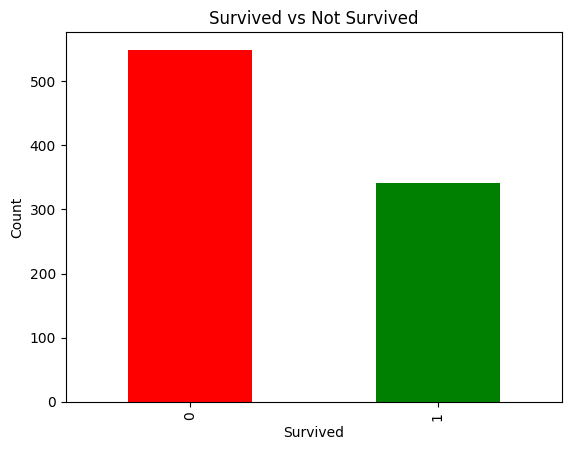

In [47]:
import matplotlib.pyplot as plt

data['Survived'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Survived vs Not Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

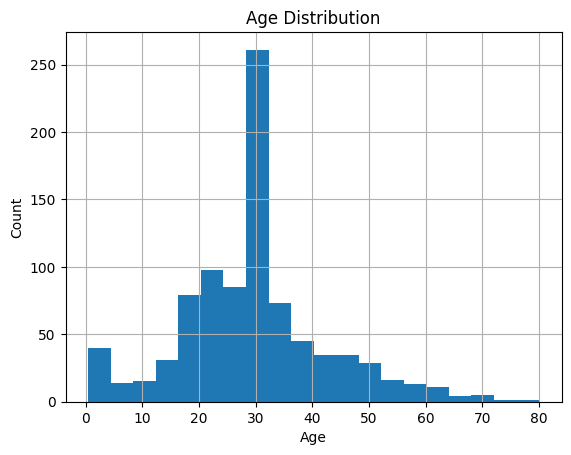

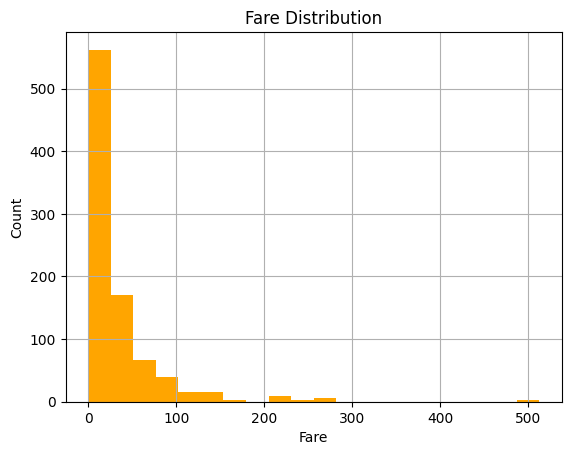

In [48]:
data['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

data['Fare'].hist(bins=20, color='orange')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

task 2 Data Preprocessing

In [3]:
from google.colab import files
import pandas as pd
import io

# File upload
uploaded = files.upload()  # Select your Titanic CSV file

# Check uploaded file name
print("Uploaded files:", uploaded.keys())

# Load CSV
file_name = list(uploaded.keys())[0]  # Automatically take first uploaded file
data = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Check first few rows
data.head()

Saving Titanic.csv to Titanic (11).csv
Uploaded files: dict_keys(['Titanic (11).csv'])


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Check missing values
print("Missing values per column:")
print(data.isnull().sum())

# Fill missing Age and Embarked
data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Embarked'] = data['Embarked'].fillna('S')

# Feature Engineering
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# Encode categorical variables safely
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

# Scale numeric features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[['Age','Fare','FamilySize']] = scaler.fit_transform(data[['Age','Fare','FamilySize']])

# Confirm preprocessing
print("Preprocessing done! First 5 rows:")
data.head()

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Preprocessing done! First 5 rows:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0.271174,1,0,A/5 21171,0.014151,NaN,0.1,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.472229,1,0,PC 17599,0.139136,C85,0.1,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0.321438,0,0,STON/O2. 3101282,0.015469,NaN,0.0,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.434531,1,0,113803,0.103644,C123,0.1,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.434531,0,0,373450,0.015713,NaN,0.0,True,False,True


In [8]:
# Check columns
print("Columns:", data.columns)

# Check target variable
print("Target values (Survived):", data['Survived'].unique())

# Confirm no missing values
print("Missing values:\n", data.isnull().sum())

Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilySize', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')
Target values (Survived): [0 1]
Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
FamilySize       0
Sex_male         0
Embarked_Q       0
Embarked_S       0
dtype: int64


task 3 Model training and Evaluation

In [9]:
from sklearn.model_selection import train_test_split

X = data.drop('Survived', axis=1)  # Features only
y = data['Survived']               # Target only

# Split safely
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Shapes: (712, 13) (179, 13) (712,) (179,)


In [14]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Sklearn (after fresh install)
!pip install --upgrade scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [16]:
# Check data types
data.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [20]:
# Check which columns are object/string type
string_cols = data.select_dtypes(include=['object']).columns
print("String/object columns found:", string_cols)

# Drop only these columns (agar aapko use nahi karna)
data = data.drop(columns=string_cols)

print("Remaining columns:", data.columns)

String/object columns found: Index([], dtype='object')
Remaining columns: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [21]:
# Encode remaining categorical columns if exist
cat_cols = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Scale numeric features
from sklearn.preprocessing import MinMaxScaler
num_cols = ['Age','Fare','FamilySize']
from sklearn.preprocessing import MinMaxScaler

# Check if these columns exist
num_cols_existing = [c for c in num_cols if c in data.columns]

scaler = MinMaxScaler()
data[num_cols_existing] = scaler.fit_transform(data[num_cols_existing])

print("Data ready for modeling! Columns now:")
print(data.columns)

Data ready for modeling! Columns now:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=500, solver='liblinear')
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Models trained successfully ✅")

Models trained successfully ✅


task 4 Model Evaluation

Saving Titanic.csv to Titanic (12).csv
--- Logistic Regression ---
Accuracy: 0.7262569832402235
Precision: 0.7551020408163265
Recall: 0.5
F1 Score: 0.6016260162601627
--- Random Forest ---
Accuracy: 0.7094972067039106
Precision: 0.6617647058823529
Recall: 0.6081081081081081
F1 Score: 0.6338028169014085


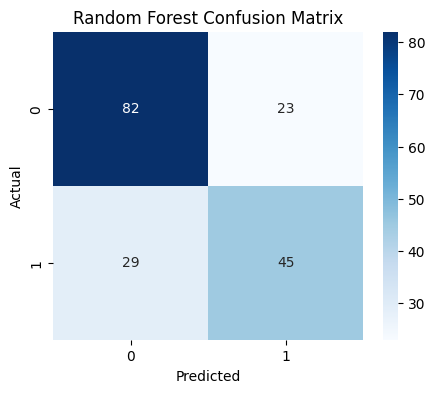

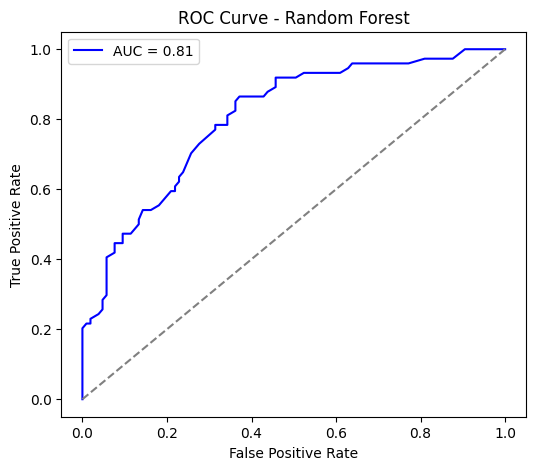

In [26]:
# Step 0: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

!pip install --upgrade scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Step 1: Upload CSV
from google.colab import files
import io

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
data = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Step 2: Preprocessing
data['Age'] = data['Age'].fillna(data['Age'].mean())
if 'Embarked' in data.columns:
    data['Embarked'] = data['Embarked'].fillna('S')

# Feature engineering
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# Drop object/string columns safely
string_cols = data.select_dtypes(include=['object']).columns
data = data.drop(columns=string_cols, errors='ignore')

# Scale numeric features
num_cols = ['Age','Fare','FamilySize']
num_cols_existing = [c for c in num_cols if c in data.columns]
scaler = MinMaxScaler()
data[num_cols_existing] = scaler.fit_transform(data[num_cols_existing])

# Step 3: Train/Test Split + Model Training + Predictions
X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=500, solver='liblinear')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 4: Evaluation
def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

# Confusion Matrix - Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve - Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='blue')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

task 5 Model *Improvement*

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# parameters
param_grid = {
    'n_estimators':[50,100],
    'max_depth':[None,5,10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 50}


In [29]:
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
0,PassengerId,0.302232
5,Fare,0.272146
2,Age,0.235510
1,Pclass,0.077937
6,FamilySize,0.050619
3,SibSp,0.034089
4,Parch,0.027466


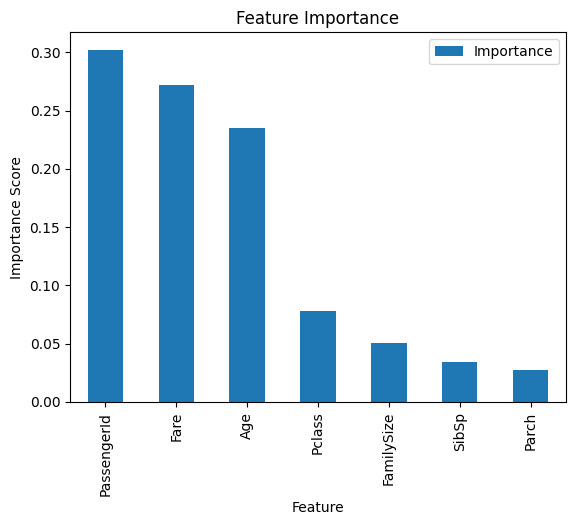

In [30]:
import matplotlib.pyplot as plt

feature_importance.plot(x='Feature', y='Importance', kind='bar')

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

task 6 Reporting

In [32]:
1. Dataset Description

In this project, the Titanic dataset was used for a classification problem. The objective of this project is to predict whether a passenger survived or not during the Titanic disaster. The dataset contains information about passengers such as their age, ticket class, fare, number of siblings/spouses aboard, and number of parents/children aboard. The target variable in the dataset is Survived, which indicates whether the passenger survived (1) or did not survive (0).

2. Data Preprocessing

Several preprocessing steps were applied to prepare the dataset for machine learning models. Missing values in the Age column were replaced with the mean value of the column. Missing values in the Embarked column were filled with the most common value. A new feature called FamilySize was created by combining the SibSp and Parch columns. Categorical columns were removed or encoded so that the machine learning algorithms could process the data. In addition, numerical features were normalized using Min-Max scaling to ensure that all features were on a similar scale.

3. Models Used

Two classification algorithms were used in this project:

Logistic Regression
Logistic Regression is a simple and widely used classification algorithm. It is effective for binary classification problems and provides a good baseline model.

Random Forest
Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

4. Model Evaluation

The performance of the models was evaluated using several metrics including Accuracy, Precision, Recall, and F1-score. These metrics help measure how well the model predicts the survival of passengers.

A Confusion Matrix was also generated to visualize the number of correct and incorrect predictions made by the model. Additionally, the ROC Curve and AUC score were used to evaluate the classification performance of the model.

5. Model Improvement

To improve the performance of the model, hyperparameter tuning was performed using GridSearchCV on the Random Forest model. This helped in selecting the best combination of parameters such as the number of trees and maximum depth. Feature importance analysis was also performed to determine which features had the most influence on the prediction results.

6. Conclusion

The results show that the Random Forest model performed better than Logistic Regression in predicting passenger survival on the Titanic dataset. Important features such as passenger class, age, and fare played a significant role in the prediction. In the future, the model performance can be further improved by applying advanced algorithms such as Gradient Boosting or XGBoost and performing additional feature engineering.

SyntaxError: invalid syntax (3665902488.py, line 1)